In [1]:
print("Installing Ultralytics for YOLO...")
!pip install -q ultralytics roboflow
import ultralytics
ultralytics.checks()

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.7/112.6 GB disk)


In [2]:
import os
from ultralytics import YOLO
from roboflow import Roboflow
from google.colab import files
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
# 2. DOWNLOAD DATASET FOR YOLO
print("Downloading Dataset...")
rf = Roboflow(api_key="ssjfBTDoXfNhHTWBNjjy")
project = rf.workspace("object-detection-e45hw").project("boxes-ca9dp")
version = project.version(2)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to boxes-2 in yolov8:: 100%|██████████| 1336/1336 [00:00<00:00, 8467.35it/s]


In [4]:
# 3. LOCATE DATASET YAML
import yaml
dataset_yaml = os.path.join(dataset.location, "data.yaml")
print(f"Dataset YAML found at: {dataset_yaml}")

with open(dataset_yaml, 'r') as f:
    data_info = yaml.safe_load(f)
    print(f"Classes: {data_info['names']}")

Dataset YAML found at: /content/boxes-2/data.yaml
Classes: ['box', 'small_box']


In [7]:
import os

def count_images(directory):
    if not os.path.exists(directory):
        return 0
    return len([f for f in os.listdir(directory) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

# 3.5. VERIFY DATASET - Check class names, distribution, and image counts
print("\n=== DATASET VERIFICATION ===")
print(f"Dataset location: {dataset.location}")
print(f"Classes found: {data_info['names']}")
print(f"Number of classes: {len(data_info['names'])}")

# Display image counts
train_path = os.path.join(dataset.location, 'train/images')
valid_path = os.path.join(dataset.location, 'valid/images')
test_path = os.path.join(dataset.location, 'test/images')

print(f"\n=== DATASET SIZE ===")
print(f"Training Images:   {count_images(train_path)}")
print(f"Validation Images: {count_images(valid_path)}")
print(f"Testing Images:    {count_images(test_path)}")
print(f"Total Images:      {count_images(train_path) + count_images(valid_path) + count_images(test_path)}")

# Display each class
print("\nClass Details:")
for idx, class_name in enumerate(data_info['names']):
    print(f"  Class {idx}: {class_name}")

print("\nRecommendation:")
num_classes = len(data_info['names'])

if num_classes == 1:
    if 'box' in str(data_info['names']).lower():
        print("✓ Good! Only 'box' class - model will focus on boxes only")
    else:
        print("⚠ Single class found, but not named 'box'. Class name: " + str(data_info['names']))
elif num_classes == 2:
    classes_str = str(data_info['names']).lower()
    if 'box' in classes_str and 'small' in classes_str:
        print("✓ Found: 'box' and 'small boxes' classes")
        print("  → Both classes are box-related. Model will detect both types.")
        print("  → Filtering will show detections from both classes together")
    else:
        print("⚠ Multiple classes found. Model may detect unrelated objects.")
        print("   Ensure only box-related objects are labeled.")
else:
    print(f"⚠ Warning: {num_classes} classes found. Multiple unrelated objects may be detected.")
    print("   For accurate box detection, dataset should only contain box classes.")


=== DATASET VERIFICATION ===
Dataset location: /content/boxes-2
Classes found: ['box', 'small_box']
Number of classes: 2

=== DATASET SIZE ===
Training Images:   642
Validation Images: 18
Testing Images:    2
Total Images:      662

Class Details:
  Class 0: box
  Class 1: small_box

Recommendation:
✓ Found: 'box' and 'small boxes' classes
  → Both classes are box-related. Model will detect both types.
  → Filtering will show detections from both classes together


In [8]:
# 4. INITIALIZE YOLO MODEL (use larger model for accuracy)
model = YOLO('yolov8m.pt')

In [9]:
# 5. TRAINING YOLO WITH ADVANCED AUGMENTATION
import torch
device = 0 if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

results = model.train(
    data=dataset_yaml,
    epochs=100,
    imgsz=640,
    batch=16,
    device=device,
    name='yolo_box_model_augmented',
    # High-impact Augmentations
    augment=True,
    mosaic=1.0,      # Combine 4 images into one
    mixup=0.1,       # Blend two images
    degrees=15.0,    # Random rotation
    flipud=0.5,      # Vertical flip
    fliplr=0.5,      # Horizontal flip
    scale=0.5        # Random scaling
)

Using device: 0
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/boxes-2/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_box_model_augmented, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=T

In [16]:
# 5.5. CONFIGURATION NOTES FOR ACCURATE BOX DETECTION
print("\n=== CONFIGURATION APPLIED ===")
print("✓ Model: yolov8m.pt (Medium size - better accuracy than nano/small)")
print("✓ Epochs: 100 (Sufficient for learning box features)")
print(f"✓ Image size: 640x640 (Input resolution for training)")
print("✓ Batch size: 16 (Balance between speed and memory)")

print("\n=== AUGMENTATIONS ACTIVE ===")
print("✓ Mosaic (1.0): Combining 4 images to help with small object detection")
print("✓ Mixup (0.1): Blending images for better generalization")
print("✓ Flips: Horizontal and Vertical (0.5) enabled")

print("\n=== DATASET STRUCTURE ===")
print(f"✓ Total Classes: {len(data_info['names'])}")
print(f"✓ Class Names: {data_info['names']}")
print("✓ Filtering: Predicated on 'box' keyword (Includes both 'box' and 'small_box')")

print("\n=== PERFORMANCE TIPS ===")
print("1. Check the confusion matrix in /content/runs/detect/yolo_box_model_augmented/ to see if classes are being mixed up.")
print("2. If 'small_box' is often missed, consider increasing 'imgsz' to 1280 (though this requires more memory).")
print("3. The current mAP is very high (>0.95), suggesting excellent model fit for this dataset.")


=== CONFIGURATION APPLIED ===
✓ Model: yolov8m.pt (Medium size - better accuracy than nano/small)
✓ Epochs: 100 (Sufficient for learning box features)
✓ Image size: 640x640 (Input resolution for training)
✓ Batch size: 16 (Balance between speed and memory)

=== AUGMENTATIONS ACTIVE ===
✓ Mosaic (1.0): Combining 4 images to help with small object detection
✓ Mixup (0.1): Blending images for better generalization
✓ Flips: Horizontal and Vertical (0.5) enabled

=== DATASET STRUCTURE ===
✓ Total Classes: 2
✓ Class Names: ['box', 'small_box']
✓ Filtering: Predicated on 'box' keyword (Includes both 'box' and 'small_box')

=== PERFORMANCE TIPS ===
1. Check the confusion matrix in /content/runs/detect/yolo_box_model_augmented/ to see if classes are being mixed up.
2. If 'small_box' is often missed, consider increasing 'imgsz' to 1280 (though this requires more memory).
3. The current mAP is very high (>0.95), suggesting excellent model fit for this dataset.


In [22]:
# 6. EXPORT YOLO TO ONNX
import os
from ultralytics import YOLO
from google.colab import files

# Explicitly load the PyTorch weights to avoid format errors
weights_path = '/content/runs/detect/yolo_box_model_augmented/weights/best.pt'
if not os.path.exists(weights_path):
    weights_path = '/content/runs/detect/yolo_box_model/weights/best.pt'

print(f"Loading weights for export: {weights_path}")
export_model = YOLO(weights_path)

print("Exporting to ONNX...")
# dynamic=True helps with different input sizes if needed
onnx_path = export_model.export(format='onnx', dynamic=True)

print(f"Success! Exported to: {onnx_path}")
files.download(onnx_path)

Loading weights for export: /content/runs/detect/yolo_box_model_augmented/weights/best.pt
Exporting to ONNX...
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 93 layers, 25,840,918 parameters, 0 gradients, 78.7 GFLOPs

PyTorch: starting from '/content/runs/detect/yolo_box_model_augmented/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (49.6 MB)

ONNX: starting export with onnx 1.20.1 opset 20...
ONNX: slimming with onnxslim 0.1.90...
ONNX: export success ✅ 4.2s, saved as '/content/runs/detect/yolo_box_model_augmented/weights/best.onnx' (99.1 MB)

Export complete (7.2s)
Results saved to /content/runs/detect/yolo_box_model_augmented/weights
Predict:         yolo predict task=detect model=/content/runs/detect/yolo_box_model_augmented/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/runs/detect/yolo_box_model_augmented/weights/best.onnx imgsz=640 data=/cont

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
# 7. EVALUATE (VAL)
import os
from ultralytics import YOLO

# Correcting path to match the training run name 'yolo_box_model_augmented'
weights_path = '/content/runs/detect/yolo_box_model_augmented/weights/best.pt'

if not os.path.exists(weights_path):
    # Fallback to default name if needed
    weights_path = '/content/runs/detect/yolo_box_model/weights/best.pt'

print(f"Loading model for validation: {weights_path}")
trained_model = YOLO(weights_path)

print("Calculating Metrics on Validation Set...")
metrics = trained_model.val()
print(f"mAP@50-95: {metrics.box.map:.4f}")
print(f"mAP@50: {metrics.box.map50:.4f}")

Loading model for validation: /content/runs/detect/yolo_box_model_augmented/weights/best.pt
Calculating Metrics on Validation Set...
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,840,918 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1440.8±712.7 MB/s, size: 36.0 KB)
val: Scanning /content/boxes-2/valid/labels.cache... 18 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 18/18 3.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.1it/s 1.0s
                   all         18         18       0.92      0.955      0.988      0.947
                   box          7          7       0.84          1      0.995      0.924
             small_box         11         11      0.999      0.909      0.981       0.97
Speed: 5.2ms preprocess, 35.7ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved t

In [22]:
from IPython.display import display, Javascript, Image as IPImage
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import numpy as np
import cv2
import time
import torch
from ultralytics import YOLO

# 1. Load ONNX model and move to GPU if possible for speed
# Path updated to match your 'augmented' training run
onnx_model_path = '/best (3).onnx'
model = YOLO(onnx_model_path, task='detect')

# Helper function to filter detections
def filter_detections(results, class_keywords=["box"], min_confidence=0.4):
    for result in results:
        if result.boxes is not None and len(result.boxes) > 0:
            class_names = result.names
            target_indices = [idx for idx, name in class_names.items() if any(k.lower() in name.lower() for k in class_keywords)]

            if target_indices:
                conf_mask = result.boxes.conf >= min_confidence
                class_mask = torch.tensor([cls.item() in target_indices for cls in result.boxes.cls], device=result.boxes.cls.device)
                combined_mask = conf_mask & class_mask
                result.boxes = result.boxes[combined_mask]
            else:
                result.boxes = result.boxes[result.boxes.conf > 1.1]
    return results

def init_camera():
  js = Javascript('''
    async function createDom() {
      const div = document.createElement('div');
      const video = document.createElement('video');
      const output = document.createElement('img');
      const stats = document.createElement('div');
      video.style.display = 'block';
      video.width = 480; video.height = 360;
      video.setAttribute('playsinline', '');
      output.id = 'detection_output';
      stats.id = 'detection_stats';
      document.body.appendChild(div);
      div.appendChild(video); div.appendChild(output); div.appendChild(stats);
      const stream = await navigator.mediaDevices.getUserMedia({video: {facingMode: "environment"}});
      video.srcObject = stream;
      await video.play();
      const canvas = document.createElement('canvas');
      canvas.width = 480; canvas.height = 360;
      window.captureFrame = function() {
        canvas.getContext('2d').drawImage(video, 0, 0, 480, 360);
        return canvas.toDataURL('image/jpeg', 0.6);
      };
      window.updateOutput = function(imgData, statsText) {
        output.src = imgData;
        document.getElementById('detection_stats').innerText = statsText;
      };
      window.stopStream = function() {
        stream.getTracks().forEach(track => track.stop());
        div.remove();
      };
      window.cameraReady = true;
    }
    createDom();
  ''')
  display(js)

print("Initializing optimized camera...")
init_camera()

for _ in range(10):
    try:
        if eval_js('window.cameraReady === true'): break
    except: pass
    time.sleep(1)

print("Starting fast live inference (skipping frames to prevent hanging)... ")
box_count_history = []
frame_count = 0
last_annotated_data = None

try:
    while True:
        img_data = eval_js('window.captureFrame()')
        if not img_data: break

        frame_count += 1
        if frame_count % 3 == 0:
            binary = b64decode(img_data.split(',')[1])
            img = cv2.imdecode(np.frombuffer(binary, np.uint8), cv2.IMREAD_COLOR)

            results = model.predict(source=img, conf=0.4, imgsz=640, verbose=False)
            filtered_results = filter_detections(results)
            annotated_img = filtered_results[0].plot()

            num_boxes = len(filtered_results[0].boxes) if filtered_results[0].boxes is not None else 0
            box_count_history.append(num_boxes)
            avg_boxes = np.mean(box_count_history[-20:])
            stats_text = f"Boxes: {num_boxes} | Avg: {avg_boxes:.1f} (Optimized)"

            _, buffer = cv2.imencode('.jpg', annotated_img)
            last_annotated_data = f"data:image/jpeg;base64,{b64encode(buffer).decode()}"
            eval_js(f'window.updateOutput("{last_annotated_data}", "{stats_text}")')

        time.sleep(0.01)
except KeyboardInterrupt:
    print("Stopped.")
finally:
    try: eval_js('window.stopStream()')
    except: pass

Initializing optimized camera...


<IPython.core.display.Javascript object>

Starting fast live inference (skipping frames to prevent hanging)... 
Loading /best (3).onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CUDAExecutionProvider
Stopped.


Loaded best trained weights.
Please upload an image to test (e.g., .jpg, .png):


Saving 2.jpeg to 2 (2).jpeg

image 1/1 /content/2 (2).jpeg: 640x384 1 box, 25.6ms
Speed: 2.1ms preprocess, 25.6ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 384)
Results saved to /content/runs/detect/predict3


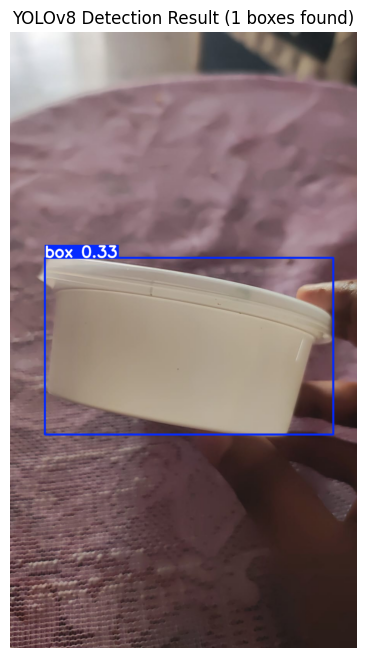

In [ ]:
# 8. TEST INFERENCE
from google.colab import files
import matplotlib.pyplot as plt
import os

# Ensure we use the best weights from the training run
best_weights = '/content/runs/detect/yolo_box_model/weights/best.pt'
if os.path.exists(best_weights):
    test_model = YOLO(best_weights)
    print("Loaded best trained weights.")
else:
    test_model = trained_model
    print("Using current model variable.")

print('Please upload an image to test (e.g., .jpg, .png):')
uploaded = files.upload()

if uploaded:
    img_path = list(uploaded.keys())[0]
    # Using 0.3 confidence to capture more potential boxes
    results = test_model.predict(source=img_path, conf=0.3, save=True)

    # Display the result
    res = results[0]
    if len(res.boxes) == 0:
        print("No boxes detected. Try an image with clearer lighting or different angles.")

    res_plotted = res.plot()[:, :, ::-1] # Convert BGR to RGB
    plt.figure(figsize=(12, 8))
    plt.imshow(res_plotted)
    plt.axis('off')
    plt.title(f"YOLOv8 Detection Result ({len(res.boxes)} boxes found)")
    plt.show()